# 05 — SMDP-Inspired Stress Policy

This notebook translates the project narrative into a finite-state stress-control layer.

The core analogy is:

| Degradation-control model | Portfolio analogue |
|---|---|
| degradation state | market / portfolio stress state |
| production speed | risk budget / allocation intensity |
| degradation intensity | probability of moving to worse stress state |
| maintenance | de-risking / defensive allocation |
| reward | risk-adjusted portfolio outcome |

The objective is not to claim that a full institutional SMDP has been solved. The objective is to build a transparent first version of the stress-state policy layer and connect it to the previous notebooks.

Expected local outputs:

- `data/processed/stress_states.csv`
- `data/processed/stress_transition_matrix.csv`
- `data/processed/stress_policy_budgets.csv`
- `data/processed/smdp_policy_comparison.csv`
- `reports/figures/05_stress_states.png`
- `reports/figures/05_stress_transition_matrix.png`
- `reports/figures/05_policy_budget.png`
- `reports/figures/05_smdp_policy_drawdowns.png`

In [ ]:
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
risk_features = pd.read_csv(DATA_DIR / "risk_features.csv", index_col=0, parse_dates=True)

existing_backtest_returns_path = DATA_DIR / "backtest_strategy_returns.csv"

if existing_backtest_returns_path.exists():
    existing_backtest_returns = pd.read_csv(
        existing_backtest_returns_path,
        index_col=0,
        parse_dates=True,
    )
else:
    existing_backtest_returns = pd.DataFrame(index=returns.index)

print("Returns:", returns.shape)
print("Features:", risk_features.shape)
print("Existing backtest returns:", existing_backtest_returns.shape)

Returns: (4850, 7)
Features: (4788, 5)
Existing backtest returns: (4788, 4)


## 2. Build finite stress states

The HMM regimes from notebook 02 are latent statistical regimes.

Here we build a separate finite-state stress layer by discretizing the transparent stress score into ordered stress states:

```text
state 0 = normal
state 1 = elevated
state 2 = fragile
state 3 = crisis

In [4]:
policy_config = StressPolicyConfig(
    n_states=4,
    calm_budget=1.00,
    elevated_budget=0.70,
    stress_budget=0.40,
    crisis_budget=0.15,
    drawdown_penalty=2.0,
    cvar_penalty=1.0,
    turnover_penalty=0.1,
)

score = stress_score(risk_features)
stress_states = build_stress_states(
    features=risk_features,
    n_states=policy_config.n_states,
    score=score,
).rename("stress_state")

state_names = {
    0: "normal",
    1: "elevated",
    2: "fragile",
    3: "crisis",
}

display(stress_states.value_counts().sort_index().rename("n_obs"))

stress_state
0    1197
1    1197
2    1197
3    1197
Name: n_obs, dtype: int64

## 3. Estimate empirical stress-state transitions

The transition matrix describes how the stress process moves from one state to another.

This is the empirical counterpart of the degradation-transition layer:

- diagonal entries describe persistence,
- upward transitions describe deterioration,
- downward transitions describe recovery.

In [5]:
stress_transition_matrix = estimate_transition_matrix(
    stress_states,
    n_states=policy_config.n_states,
)

display(stress_transition_matrix)

,state_0,state_1,state_2,state_3
state_0,0.9231,0.0744,0.0025,0.0000
state_1,0.0727,0.8329,0.0911,0.0033
state_2,0.0033,0.0920,0.8445,0.0602
state_3,0.0000,0.0008,0.0627,0.9365


## 4. Define a threshold risk-budget policy

The first intervention policy is intentionally transparent:

| Stress state | Interpretation | Risk budget |
|---|---|---|
| 0 | normal | 1.00 |
| 1 | elevated | 0.70 |
| 2 | fragile | 0.40 |
| 3 | crisis | 0.15 |

This is a threshold-style policy. It reduces allocation intensity as the portfolio moves into more fragile states.

In [6]:
stress_policy_budgets = threshold_risk_budget_policy(
    stress_states,
    budgets=policy_config.default_budgets,
)

policy_table = pd.DataFrame(
    {
        "state": list(policy_config.default_budgets.keys()),
        "label": [state_names[i] for i in policy_config.default_budgets],
        "risk_budget": list(policy_config.default_budgets.values()),
    }
)

display(policy_table)
display(stress_policy_budgets.tail())

,state,label,risk_budget
0,0,normal,1.0000
1,1,elevated,0.7000
2,2,fragile,0.4000
3,3,crisis,0.1500


Date
2026-06-04   0.7000
2026-06-05   0.4000
2026-06-08   0.4000
2026-06-09   0.4000
2026-06-10   0.4000
Name: risk_budget, dtype: float64

## 5. Visual diagnostic — stress states

This plot checks whether the stress-state construction is readable over time.

It should be interpreted as a finite-state stress indicator, not as a perfect crisis predictor.

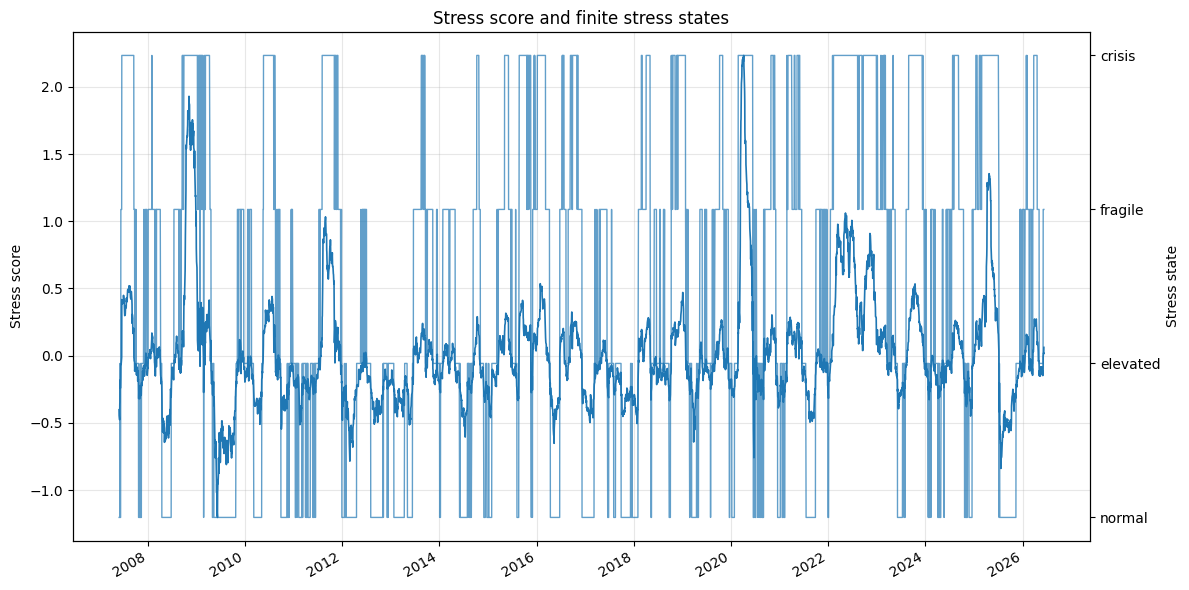

In [7]:
plot_df = pd.concat(
    [
        score.rename("stress_score"),
        stress_states.rename("stress_state"),
    ],
    axis=1,
).dropna()

fig, ax1 = plt.subplots(figsize=(12, 6))

plot_df["stress_score"].plot(ax=ax1, linewidth=1.2)
ax1.set_title("Stress score and finite stress states")
ax1.set_ylabel("Stress score")
ax1.set_xlabel("")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
plot_df["stress_state"].plot(ax=ax2, linewidth=1.0, alpha=0.7)
ax2.set_ylabel("Stress state")
ax2.set_yticks(list(state_names.keys()))
ax2.set_yticklabels([state_names[i] for i in state_names])

fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_stress_states.png", dpi=150)
plt.show()

## 6. Visual diagnostic — stress transition matrix

The transition matrix should be inspected as a model-risk object.

A credible stress-state process should show persistence, but not be completely absorbing. Crisis states should be reachable and recoverable in the historical sample.

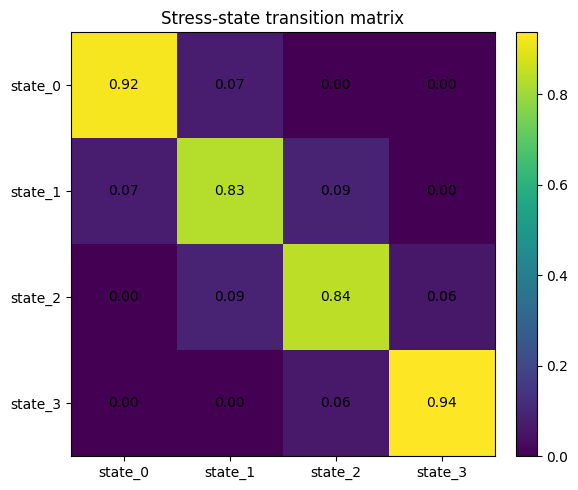

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(stress_transition_matrix.values)
ax.set_title("Stress-state transition matrix")
ax.set_xticks(range(stress_transition_matrix.shape[1]))
ax.set_yticks(range(stress_transition_matrix.shape[0]))
ax.set_xticklabels(stress_transition_matrix.columns)
ax.set_yticklabels(stress_transition_matrix.index)

for i in range(stress_transition_matrix.shape[0]):
    for j in range(stress_transition_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{stress_transition_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_stress_transition_matrix.png", dpi=150)
plt.show()

## 7. Visual diagnostic — risk budget over time

The risk-budget series is the intervention layer.

It makes the policy auditable: we can see exactly when and how much the portfolio is being de-risked.

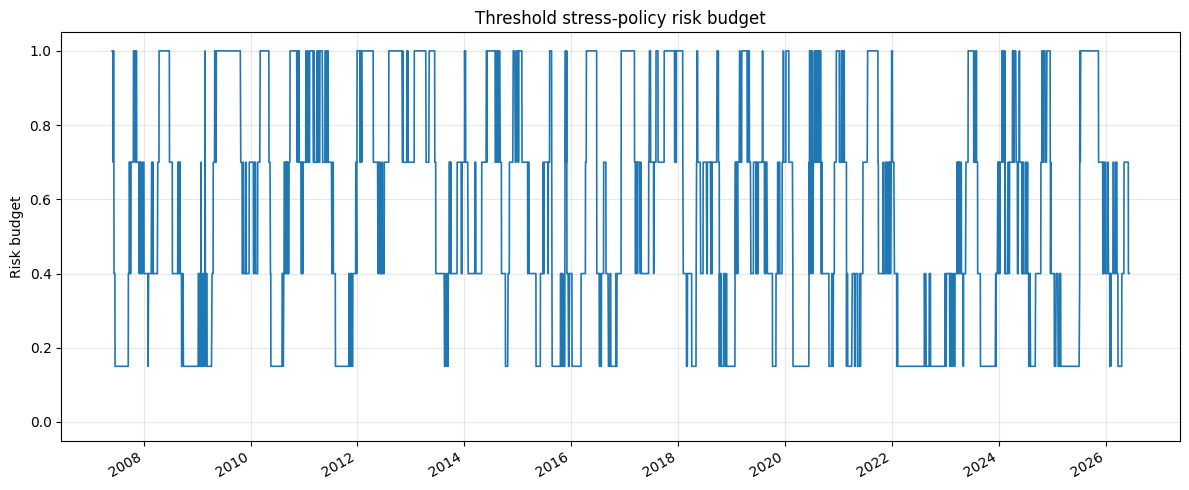

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

stress_policy_budgets.plot(ax=ax, linewidth=1.2)

ax.set_title("Threshold stress-policy risk budget")
ax.set_ylabel("Risk budget")
ax.set_xlabel("")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_policy_budget.png", dpi=150)
plt.show()

## 8. Backtest the stress-policy allocation

We now compare:

1. equal weight,
2. minimum variance,
3. SMDP-inspired stress-policy minimum variance.

The stress-policy strategy uses the finite stress state as the control state and maps it to a risk budget.

In [10]:
smdp_strategies = {
    "equal_weight": lambda history, current_regime=None: equal_weight(history.columns),
    "minimum_variance": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
    ),
    "smdp_stress_policy": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
        budgets=policy_config.default_budgets,
    ),
}

smdp_results = {}

for name, strategy_fn in smdp_strategies.items():
    use_states = stress_states if name == "smdp_stress_policy" else None

    smdp_results[name] = run_backtest(
        returns=returns,
        strategy_fn=strategy_fn,
        regimes=use_states,
        lookback=252,
        rebalance_frequency="ME",
        transaction_cost_bps=2.0,
    )

smdp_strategy_returns = pd.concat(
    {name: result.returns for name, result in smdp_results.items()},
    axis=1,
)

smdp_strategy_returns.columns = list(smdp_results.keys())

smdp_summary = compare_strategies(smdp_strategy_returns)

display(smdp_summary)

,ann_return,ann_vol,sharpe_0rf,sortino_0rf,max_drawdown,calmar,cvar_5pct,skew,kurtosis
smdp_stress_policy,0.0357,0.0368,0.9685,1.5386,-0.0680,0.5249,0.0055,-0.5631,5.6648
equal_weight,0.0442,0.0576,0.7673,1.2270,-0.1425,0.3099,0.0085,-0.3489,4.7414
minimum_variance,0.0442,0.0576,0.7673,1.2270,-0.1425,0.3099,0.0085,-0.3489,4.7414


## 9. Stress-adjusted reward diagnostic

The stress-adjusted reward penalizes losses occurring in severe stress states.

This is not a final utility function. It is a transparent diagnostic that aligns the evaluation with the project narrative:

> losses in fragile or crisis states are more costly than losses in normal states.

In [11]:
stress_adjusted_rewards = {}

for name in smdp_strategy_returns.columns:
    stress_adjusted_rewards[name] = stress_adjusted_reward(
        portfolio_returns=smdp_strategy_returns[name],
        stress_states=stress_states,
        config=policy_config,
    )

stress_adjusted_rewards = pd.concat(stress_adjusted_rewards, axis=1)

reward_summary = pd.DataFrame(
    {
        "mean_daily_stress_adjusted_reward": stress_adjusted_rewards.mean(),
        "annualized_stress_adjusted_reward": stress_adjusted_rewards.mean() * 252,
    }
)

smdp_policy_comparison = smdp_summary.join(reward_summary)

display(smdp_policy_comparison)

,ann_return,ann_vol,sharpe_0rf,sortino_0rf,max_drawdown,calmar,cvar_5pct,skew,kurtosis,mean_daily_stress_adjusted_reward,annualized_stress_adjusted_reward
smdp_stress_policy,0.0357,0.0368,0.9685,1.5386,-0.0680,0.5249,0.0055,-0.5631,5.6648,-0.0006,-0.1426
equal_weight,0.0442,0.0576,0.7673,1.2270,-0.1425,0.3099,0.0085,-0.3489,4.7414,-0.0013,-0.3184
minimum_variance,0.0442,0.0576,0.7673,1.2270,-0.1425,0.3099,0.0085,-0.3489,4.7414,-0.0013,-0.3184


## 10. Optional value-iteration illustration

The current project has enough structure to illustrate value iteration, but not enough evidence to claim a fully calibrated SMDP.

The following cell is therefore a transparent methodological bridge. It uses empirical state rewards and simple action labels to show how a finite-state policy could be extended toward stochastic control.

Interpretation caution:

> this is a stylized control diagnostic, not a production-calibrated SMDP.

In [12]:
aligned_reward_data = pd.concat(
    [
        returns.mean(axis=1).rename("equal_weight_return"),
        stress_states.rename("stress_state"),
    ],
    axis=1,
).dropna()

state_mean_returns = (
    aligned_reward_data
    .groupby("stress_state")["equal_weight_return"]
    .mean()
    .reindex(range(policy_config.n_states))
    .fillna(0.0)
)

severity = pd.Series(
    np.linspace(0.0, 1.0, policy_config.n_states),
    index=range(policy_config.n_states),
)

base_transition = stress_transition_matrix.copy()

# Stylized action rewards: lower budgets sacrifice expected return but reduce stress penalty.
reward_by_action = {
    "maintain": state_mean_returns.to_numpy() - 0.0010 * severity.to_numpy(),
    "moderate_de_risk": 0.70 * state_mean_returns.to_numpy() - 0.0006 * severity.to_numpy(),
    "strong_de_risk": 0.40 * state_mean_returns.to_numpy() - 0.0003 * severity.to_numpy(),
}

# Stylized transition scenarios based on the empirical matrix.
# The transition matrix itself remains empirical for "maintain".
transition_by_action = {
    "maintain": base_transition,
    "moderate_de_risk": base_transition.copy(),
    "strong_de_risk": base_transition.copy(),
}

for action, shift in [("moderate_de_risk", 0.05), ("strong_de_risk", 0.10)]:
    matrix = transition_by_action[action].copy()

    for i in range(policy_config.n_states):
        if i > 0:
            moved_mass = min(shift, matrix.iloc[i].sum())
            matrix.iloc[i, i] = max(0.0, matrix.iloc[i, i] - moved_mass)
            matrix.iloc[i, i - 1] = matrix.iloc[i, i - 1] + moved_mass

    matrix = matrix.div(matrix.sum(axis=1), axis=0)
    transition_by_action[action] = matrix

value, illustrative_policy = value_iteration(
    transition_by_action=transition_by_action,
    reward_by_action=reward_by_action,
    gamma=0.95,
)

display(value)
display(pd.Series(illustrative_policy, name="illustrative_action"))

state_0    0.0036
state_1    0.0021
state_2    0.0006
state_3   -0.0008
Name: value, dtype: float64

0          maintain
1    strong_de_risk
2    strong_de_risk
3    strong_de_risk
Name: illustrative_action, dtype: object

## 11. Visual diagnostic — drawdown comparison

The final policy comparison focuses on drawdown.

The relevant question is not whether the stress policy always dominates. The relevant question is whether it provides an interpretable reduction in downside exposure during fragile states.

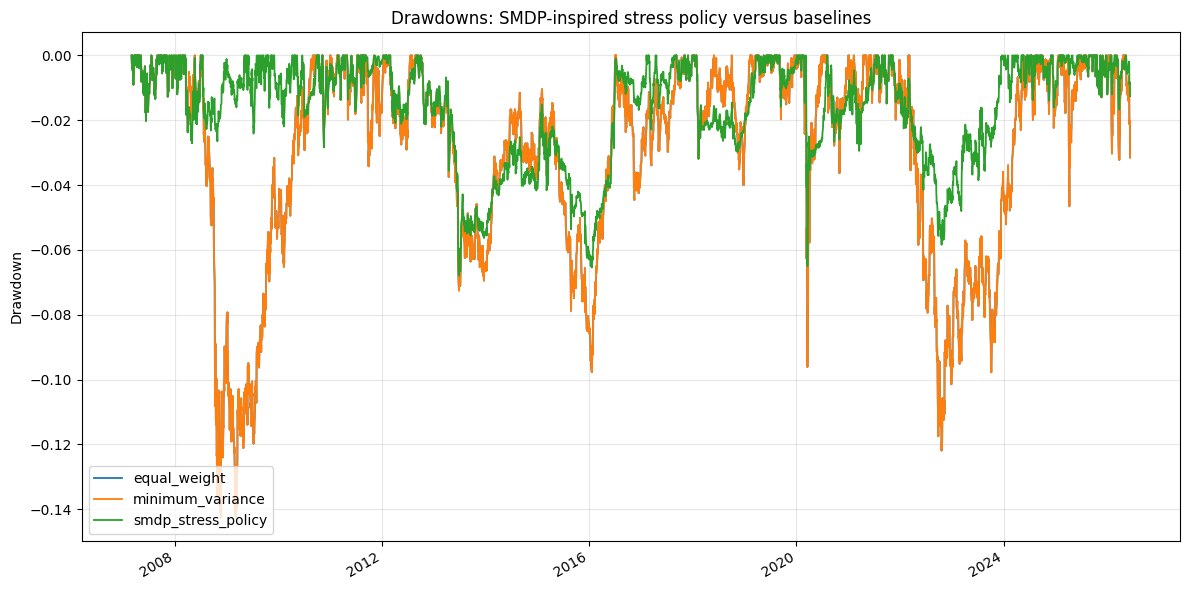

In [13]:
smdp_drawdowns = smdp_strategy_returns.apply(drawdown_series)

fig, ax = plt.subplots(figsize=(12, 6))

smdp_drawdowns.plot(ax=ax, linewidth=1.3)

ax.set_title("Drawdowns: SMDP-inspired stress policy versus baselines")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_smdp_policy_drawdowns.png", dpi=150)
plt.show()

## 12. Export stress-policy outputs

These files document the stress-state layer and make the final policy comparison reproducible.

In [14]:
stress_states.to_frame().to_csv(DATA_DIR / "stress_states.csv")
stress_transition_matrix.to_csv(DATA_DIR / "stress_transition_matrix.csv")
policy_table.to_csv(DATA_DIR / "stress_policy_budgets.csv", index=False)
smdp_policy_comparison.to_csv(DATA_DIR / "smdp_policy_comparison.csv")
smdp_strategy_returns.to_csv(DATA_DIR / "smdp_strategy_returns.csv")

print("Saved:")
print(DATA_DIR / "stress_states.csv")
print(DATA_DIR / "stress_transition_matrix.csv")
print(DATA_DIR / "stress_policy_budgets.csv")
print(DATA_DIR / "smdp_policy_comparison.csv")
print(DATA_DIR / "smdp_strategy_returns.csv")

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/stress_states.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/stress_transition_matrix.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/stress_policy_budgets.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/smdp_policy_comparison.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/smdp_strategy_returns.csv


## 13. Final notebook takeaway

This notebook completes the first version of the project pipeline.

The main contribution is not a claim of predictive alpha. The contribution is a coherent, auditable framework:

```text
market data
  -> interpretable risk features
  -> ordered regimes
  -> regime-conditioned risk diagnostics
  -> allocation backtest
  -> finite stress states
  -> threshold-style risk-budget intervention